In [49]:
#%pip install imbalanced-learn

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Modelos de clasificación
from sklearn.tree import plot_tree

#Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

In [51]:
url_SocialMediaP = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv"

dt_SocialMediaP = pd.read_csv(url_SocialMediaP, sep= ",")

print("Primeras filas")
dt_SocialMediaP.head()

Primeras filas


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [52]:
dt_SocialMediaP.describe(include="all")

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


In [53]:
print("Dimensiones:", dt_SocialMediaP.shape)

print("\nInformación general")
dt_SocialMediaP.info()

print("\nTipos de datos")
print(dt_SocialMediaP.dtypes)

Dimensiones: (6000, 9)

Información general
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB

Tipos de datos
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              

In [54]:
print("Valores nulos por columna")
print(dt_SocialMediaP.isnull().sum())

print("\nDuplicados:", dt_SocialMediaP.duplicated().sum())

Valores nulos por columna
age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

Duplicados: 0


In [55]:
#Eliminando nulls del dataset.

# Rellenar con la media Valores numericos(float)
dt_SocialMediaP = dt_SocialMediaP.fillna(dt_SocialMediaP.mean(numeric_only=True))

#Rellenar con la moda el addition_level(str)
dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].fillna(
    dt_SocialMediaP["addiction_level"].mode()[0]
)

print("\nNulos después:")
print(dt_SocialMediaP.isnull().sum())

print("\nTamaño final:")
print(dt_SocialMediaP.shape)


Nulos después:
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

Tamaño final:
(6000, 9)


In [56]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

# CAMBIO AQUÍ: Usamos una lista para incluir "object" y "str" explícitamente
for col in dt_SocialMediaP.select_dtypes(include=["object", "str"]).columns:
    if col == "addiction_level":
        dt_SocialMediaP[col] = dt_SocialMediaP[col].map(jerarquia)
    else:
        dt_SocialMediaP[col] = le.fit_transform(dt_SocialMediaP[col])

dt_SocialMediaP.info()
#Valores del addiction_level
dt_SocialMediaP['addiction_level'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   float64
 1   daily_screen_time      6000 non-null   float64
 2   social_media_hours     6000 non-null   float64
 3   study_hours            6000 non-null   float64
 4   sleep_hours            6000 non-null   float64
 5   notifications_per_day  6000 non-null   float64
 6   focus_score            6000 non-null   float64
 7   addiction_level        6000 non-null   int64  
 8   productivity_score     6000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


array([1, 0, 2])

In [57]:
mapa_adiccion = {0: "Low", 1: "Medium", 2: "High"}

dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].map(mapa_adiccion)

dt_SocialMediaP.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


## Hallazgos EDA


Durante el análisis exploratorio preliminar se logran observar 2 variables objetivo **productivity_score** y **addiction_level** siendo estas las de mayor relevancia para el conjunto de datos analizado. De igual manera se observó que las variables numéricas presentan distribuciones relativamente estables, con una mayor concentración de registros en rangos medios de *productivity_score* y *focus_score*, lo que sugiere un comportamiento general consistente en los niveles de productividad y enfoque de los usuarios.

El mapa de correlación evidenció una relación negativa entre *social_media_hours* y *productivity_score*, indicando que, a medida que aumentan las horas dedicadas a redes sociales, la productividad tiende a disminuir. De manera complementaria, la variable *sleep_hours* mostró una asociación positiva con *focus_score*, sugiriendo que mayores horas de descanso se relacionan con mejores niveles de concentración.

Finalmente, el gráfico de distribución de la productividad según *addiction_level* permitió identificar que los usuarios con un nivel de adicción alto (High) presentan medianas de productividad más bajas, reforzando la hipótesis de que un mayor grado de dependencia al uso de redes sociales impacta negativamente en el desempeño de las actividades diarias.

### Reglas del ejercicio para modelo básico
- El dataset escogido ha de contar, como mínimo, con **1000 instancias** y el grupo deberá trabajar con todas ellas. Se deberá consensuar qué fracción se emplea para entrenar los modelos y la fracción que se usa para el test de los mismos, **siempre que se haga uso en total de al menos 1000 instancias** en todos los modelos.
    - Distribución: 80 training, 20 testing
- El problema de clasificación a resolver contará con, al menos, una *variable categórica* de **al menos 5 clases posibles a la salida**, y que dependa de, **al menos, 6 variables/atributos de entrada**.

El Dataset cumple la mayoría de las reglas con excepción del número de clases a la salida.
- *addiction_level* tiene tres clases (Low, Medium, High).
- Una propuesta es convertir el valor de *productivity_score* a cinco categorías.
    - Los valores de la variable van del 0 al 100, se convierten en 5 categorías de productividad.

**Rango** | **Clase** |
----------|------------
0-20      |  Muy baja |
21-40     |  Baja     |
41-60     |  Media    |
61-80     |  Alta     |
81-100    |  Muy Alta |

### Métodos de Clasificación no basados en Redes Neuronales
**Propuesta.**
- Predicción de la Productividad

**Variable objetivo**
- productivity_level

**Variables influyentes**
 #  | **Variable**       | **Correlación** | **Interpretación**                      |
 -- |--------------------|-----------------|-----------------------------------------|
 1  | study_hours        | 0.72            | estudiar aumenta productividad          |
 2  | focus_score        | 0.56            | mayor concentración mejora resultados   |
 3  | sleep_hours        | 0.22            | dormir mejor ayuda ligeramente          |
 4  | daily_screen_time  | -0.4            | exceso de pantalla reduce productividad |
 5  | social_media_hours | -0.5            | redes sociales afectan desempeño        |
 6  | addiction_level    | -0.45           | adicción digital reduce productividad   |


**Planteamiento del problema**
- ¿Cómo predecir la productividad de una persona a partir de sus hábitos digitales y de estudio?

El factor más determinante del sistema es:
- social_media_hours - El exceso de redes sociales reduce la productividad.

porque afecta directamente:
- adicción
- concentración
- productividad

Por lo tanto, cualquier estrategia de mejora del desempeño debe controlar el uso de redes sociales.

In [58]:
# Crear una copia del DataFrame para análisis posterior
dt_SocialMediaP_Class = dt_SocialMediaP.copy()

### Conversión de *productivity_score* a cinco categorías, creación de *productivity_level*

In [59]:
bins = [0,20,40,60,80,100]
labels = ['Muy baja','Baja','Media','Alta','Muy alta']

dt_SocialMediaP_Class['productivity_level'] = pd.cut(
    dt_SocialMediaP_Class['productivity_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dt_SocialMediaP_Class[['productivity_score','productivity_level']].head()

,productivity_score,productivity_level
0,28.49,Baja
1,18.54,Muy baja
2,68.52,Alta
3,27.82,Baja
4,51.09,Media


### Distribución de Clases

In [60]:
dt_SocialMediaP_Class['productivity_level'].value_counts()

productivity_level
Muy baja    1843
Baja        1466
Media       1315
Alta         931
Muy alta     445
Name: count, dtype: int64

## Preparar variables de entrada y salida

In [61]:
#Eliminamos la variable objetivo y la variable original de productividad para crear el conjunto de características (X) y la variable objetivo (y).
Xcl = dt_SocialMediaP_Class.drop(columns=['productivity_level','productivity_score'])
ycl = dt_SocialMediaP_Class['productivity_level']

## Codificar variables categóricas

In [62]:
encoder = LabelEncoder()
Xcl['addiction_level'] = encoder.fit_transform(Xcl['addiction_level'])

## División entrenamiento y prueba

In [85]:
Xcl_train, Xcl_test, ycl_train, ycl_test = train_test_split(
    Xcl,
    ycl,
    test_size=0.2,
    random_state=42,
    stratify=ycl
)

print(f"Conjunto de entrenamiento: {Xcl_train.shape}")
print(f"Conjunto de prueba: {Xcl_test.shape}")
print(f"Características utilizadas: {Xcl.columns.tolist()}")

Conjunto de entrenamiento: (4800, 8)
Conjunto de prueba: (1200, 8)
Características utilizadas: ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'addiction_level']


## Balanceo con SMOTE + Undersampling

In [64]:
smote = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('under', under)
])

X_resampled, y_resampled = pipeline.fit_resample(Xcl_train, ycl_train)

pd.Series(y_resampled).value_counts()

productivity_level
Muy baja    1474
Baja        1474
Media       1474
Alta        1474
Muy alta    1474
Name: count, dtype: int64

## Entrenamiento con Random Forest

In [76]:
rf = RandomForestClassifier(criterion='gini', n_estimators=200, max_depth=8, min_samples_split=6, min_samples_leaf=2,
                  max_features='sqrt', bootstrap=True, oob_score=True, class_weight='balanced',
                  n_jobs=1, random_state=42)
rf.fit(X_resampled, y_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
# ============================================================
# VISUALIZACIÓN DE UN ÁRBOL DEL RANDOM FOREST
# ============================================================
# Seleccionamos uno de los árboles del bosque
tree_from_forest = rf.estimators_[0]
plt.figure(figsize=(20,10))

plot_tree(
    tree_from_forest,
    feature_names=Xcl.columns,
    class_names = dt_SocialMediaP_Class["productivity_level"].unique(),
    filled=True,
    rounded=True
)

plt.title("Uno de los árboles del Random Forest")
plt.show()

In [86]:
pred_rf = rf.predict(Xcl_test)

print('Accuracy Random Forest:', accuracy_score(ycl_test, pred_rf))
print(classification_report(ycl_test, pred_rf))

Accuracy Random Forest: 0.6391666666666667
              precision    recall  f1-score   support

        Alta       0.58      0.58      0.58       186
        Baja       0.53      0.52      0.53       293
       Media       0.55      0.62      0.58       263
    Muy alta       0.61      0.64      0.63        89
    Muy baja       0.85      0.78      0.81       369

    accuracy                           0.64      1200
   macro avg       0.62      0.63      0.62      1200
weighted avg       0.65      0.64      0.64      1200



### Evaluación del modelo básico en el conjunto de prueba - Aún en curso (errores por corregir)

In [ ]:
# Evaluación del modelo en el conjunto de prueba

# Realizar predicciones
y_pred = rf.predict(Xcl_test)

# Calcular métricas de evaluación
#mse = mean_squared_error(ycl_test, y_pred)
#mae = mean_absolute_error(ycl_test, y_pred)
#r2 = r2_score(ycl_test, y_pred)

print(f"Evaluación del modelo en el conjunto de prueba:")
#print(f"Mean Squared Error (MSE): {mse:.4f}")
#print(f"Mean Absolute Error (MAE): {mae:.4f}")
#print(f"R² Score: {r2:.4f}")

# Visualizar predicciones vs valores reales
#plt.figure(figsize=(10, 6))
#plt.scatter(ycl_test, y_pred, alpha=0.5)
#plt.plot([ycl_test.min(), ycl_test.max()], [ycl_test.min(), ycl_test.max()], 'r--', lw=2)
#plt.xlabel('Nivel de Productividad Real')
#plt.ylabel('Nivel de Productividad Predicho')
#plt.title('Predicciones vs Valores Reales')
#plt.grid(True)
#plt.show()

## Matriz de confusión

In [87]:
cm = confusion_matrix(ycl_test, pred_rf)
print(cm)

[[107   3  43  33   0]
 [  9 153  81   1  49]
 [ 39  57 162   2   3]
 [ 29   0   3  57   0]
 [  0  74   7   0 288]]


Visualización de matriz de confusión Random Forest.

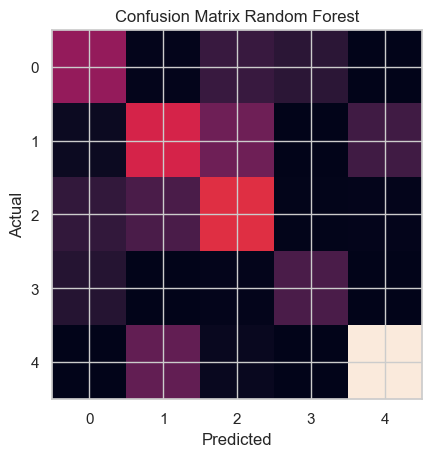

In [88]:
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Importancia de variables

In [89]:
importances = rf.feature_importances_
features = Xcl.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
3,study_hours,0.408603
6,focus_score,0.165967
2,social_media_hours,0.137548
4,sleep_hours,0.081931
1,daily_screen_time,0.072118
7,addiction_level,0.065509
5,notifications_per_day,0.038906
0,age,0.029417


<Figure size 640x480 with 0 Axes>

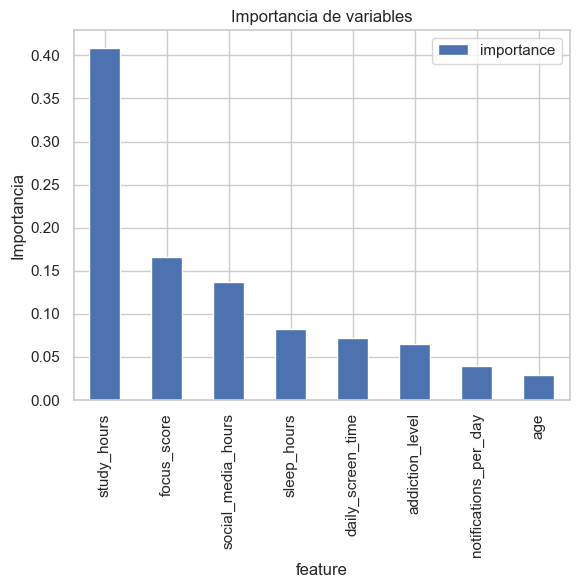

In [90]:
plt.figure()
importance_df.plot(x='feature', y='importance', kind='bar')
plt.title('Importancia de variables')
plt.ylabel('Importancia')
plt.show()

## Conclusiones

- El balanceo de clases mejora la capacidad del modelo para detectar clases minoritarias.
- Random Forest suele ofrecer mejor desempeño que Decision Tree.
- La importancia de variables permite identificar los factores que más influyen en la productividad.
